In [1]:
# --! include root folders into PYTHONPATH

import os
import sys

curr_dir = os.getcwd()
example_dir = os.path.abspath(os.path.join(curr_dir, '..'))
sys.path.append(example_dir)
root_dir = os.path.abspath(os.path.join(curr_dir, '..', '..', '..'))
sys.path.append(root_dir)

# --! import Python libraries

import torch
import torch.nn.functional as F
import numpy as np
from matplotlib import pyplot as plt

# --! import framework libraries

import example_mujoco
import util_data
import util_nn

data_dir = '../../../data/mujoco/hopper'
model_dir = '../../../models/mujoco/hopper'
result_dir = '../../../results/mujoco/hopper'

data_suffix = ''

In [2]:
# --! initialize random seed

seeds = [3, 123, 2026, 8192, 65536]
seed = seeds[1]

util_nn.set_seed(seed)

print(f'setting seed {seed}')

setting seed 123


### Creating baseline dataset

In [3]:
data_nsample = 918
data = util_data.read_datafile(f'{data_dir}/baseline{data_suffix}', data_nsample)
print(f'read data shape: {data.shape}')

obs_ndim = 11
act_ndim = 3
obs, act = torch.split(data, [obs_ndim, act_ndim], dim=-1)
print(f'read observations shape: {obs.shape}')
print(f'read actions shape: {act.shape}')

std_min = torch.tensor(1e-3, dtype=torch.float32)

# --! get normalization constants per observation
obs_mean = [s.mean() for s in torch.split(obs, 1, dim=-1)]
obs_std = [torch.maximum(s.std(), std_min) for s in torch.split(obs, 1, dim=-1)]

# --! normalize observations
obs = torch.cat([
    example_mujoco.normalize_standard(
        s, mean, std) for s, mean, std in zip(torch.split(obs, 1, dim=-1), obs_mean, obs_std)], dim=-1)

train_obs = obs[:, :-1]
train_next_obs = obs[:, 1:]
train_act = act[:, :-1]
print(f'shape of observations for training: {train_obs.shape}')
print(f'shape of next observations for training: {train_next_obs.shape}')
print(f'shape of actions for training: {train_act.shape}')

dataset = example_mujoco.baseline_dataset(train_obs, train_act, train_next_obs)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

read data shape: torch.Size([50, 918, 14])
read observations shape: torch.Size([50, 918, 11])
read actions shape: torch.Size([50, 918, 3])
shape of observations for training: torch.Size([50, 917, 11])
shape of next observations for training: torch.Size([50, 917, 11])
shape of actions for training: torch.Size([50, 917, 3])


### Training mixture of experts

In [4]:
model = example_mujoco.model_moe(obs_ndim, act_ndim, nexpert=4, smoothing=None, gumbel=None)
model.train()
example_mujoco.train_moe(model, dataloader, nepoch=500, ent_coef=0.01)

epoch 0, loss: 0.017990
epoch 20, loss: -0.007665
epoch 40, loss: -0.010095
epoch 60, loss: -0.011164
epoch 80, loss: -0.011691
epoch 100, loss: -0.012101
epoch 120, loss: -0.012408
epoch 140, loss: -0.012396
epoch 160, loss: -0.012771
epoch 180, loss: -0.012911
epoch 200, loss: -0.013029
epoch 220, loss: -0.013133
epoch 240, loss: -0.012196
epoch 260, loss: -0.013209
epoch 280, loss: -0.013328
epoch 300, loss: -0.013388
epoch 320, loss: -0.013437
epoch 340, loss: -0.013478
epoch 360, loss: -0.013429
epoch 380, loss: -0.013450
epoch 400, loss: -0.013552
epoch 420, loss: -0.013583
epoch 440, loss: -0.013604
epoch 460, loss: -0.013622
epoch 480, loss: -0.012879


In [5]:
# --! compute model capacity

nparam = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'number of trainable parameters in model ensemble: {nparam/1e6}M')

number of trainable parameters in model ensemble: 1.106352M


# Evaluating mixture of experts baseline

In [6]:
eval_data = util_data.read_datafile(f'{data_dir}/eval', data_nsample)
print(f'read evaluation data shape: {eval_data.shape}')

eval_obs, eval_act = torch.split(eval_data, [obs_ndim, act_ndim], dim=-1)
print(f'read evaluation observations shape: {eval_obs.shape}')
print(f'read evaluation actions shape: {eval_act.shape}')

# --! normalize evaluation data
eval_obs = torch.cat([
    example_mujoco.normalize_standard(
        s, mean, std) for s, mean, std in zip(torch.split(eval_obs, 1, dim=-1), obs_mean, obs_std)], dim=-1)

model.eval()

read evaluation data shape: torch.Size([30, 918, 14])
read evaluation observations shape: torch.Size([30, 918, 11])
read evaluation actions shape: torch.Size([30, 918, 3])


model_moe(
  (experts): ModuleList(
    (0-3): 4 x expert_dynamics(
      (net): Sequential(
        (0): Linear(in_features=14, out_features=512, bias=True)
        (1): ReLU()
        (2): Linear(in_features=512, out_features=512, bias=True)
        (3): ReLU()
        (4): Linear(in_features=512, out_features=11, bias=True)
      )
    )
  )
  (gate): Sequential(
    (0): Linear(in_features=14, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=4, bias=True)
  )
)

In [12]:
reanchor_nsample = 1_000_000 # ensure no re-anchoring
this_traj = 1

model.reset()

s0 = eval_obs[this_traj, 0]
rollout_traj = example_mujoco.rollout_moe(model, s0, eval_obs[this_traj], eval_act[this_traj], reanchor_nsample=reanchor_nsample)
print(f'rollout shape: {rollout_traj.shape}')

rollout shape: torch.Size([919, 11])


### Plotting rollout results

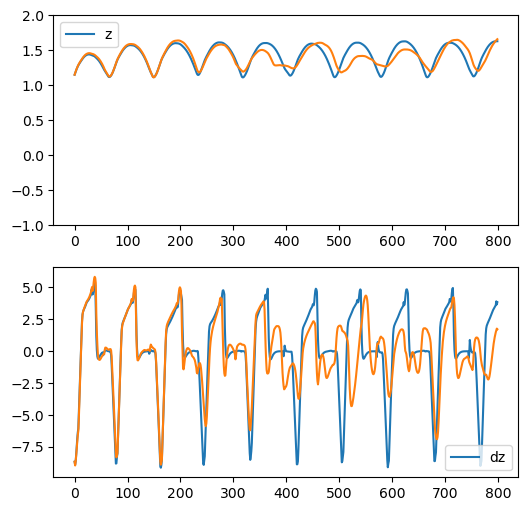

In [14]:
disp_end = 800
datasaved = False

plot_obs, plot_rollout = example_mujoco.disp_rollout(eval_obs, rollout_traj, obs_mean, obs_std, this_traj, disp_end)

if datasaved:
    save_step = torch.arange(eval_obs.shape[1]).reshape(1, -1, 1)
    save_obs = plot_obs[[this_traj]]
    savedata = np.concatenate([
        save_step[:1, :disp_end, :1],
        save_obs[:1, :disp_end, :1], save_obs[:1, :disp_end, [9]],
        plot_rollout[:1, :disp_end, :1], plot_rollout[:1, :disp_end, [9]]], axis=2)
    util_data.write_datafile(f'{result_dir}/moe_rollout_seed_{seed}', savedata, delim=' ')

### Analyzing mse vs. rollout horizon

In [ ]:
traj_mse = []
with torch.no_grad():
    for j in range(eval_obs.shape[0]): # trajectory
        print(f'processing trajectory {j+1} out of {eval_obs.shape[0]}')
        mse = []
        for h in range(1, eval_obs.shape[1]): # horizon
            s0 = eval_obs[j, 0]
            model.reset()
            cmp_rollout = example_mujoco.rollout_moe(
                model, s0,
                eval_obs[j, :h], eval_act[j, :h], reanchor_nsample=reanchor_nsample)

            # --! denormalize results
            cmp_rollout = torch.unsqueeze(cmp_rollout, 0)
            cmp_rollout = torch.cat([
                example_mujoco.denormalize_standard(
                    s, mean, std) for s, mean, std in zip(torch.split(cmp_rollout, 1, dim=-1), obs_mean, obs_std)], dim=-1)
            cmp_obs = torch.cat([
                example_mujoco.denormalize_standard(
                    s, mean, std) for s, mean, std in zip(torch.split(eval_obs[[j], :(h+1)], 1, dim=-1), obs_mean, obs_std)], dim=-1)

            # --! compute error
            loss = F.mse_loss(cmp_rollout, cmp_obs)
            mse.append(loss)
            if h % 100 == 0:
                print(f'\thorizon {h} out of {obs.shape[1]}, loss: {loss}')
        mse = torch.stack(mse)
        traj_mse.append(mse)
    traj_mse = torch.stack(traj_mse)

In [ ]:
traj_mse_mean = torch.mean(traj_mse, dim=0)
traj_mse_std = torch.std(traj_mse, dim=0)

print(traj_mse_mean[0])
print(traj_mse_std[0])

with torch.no_grad():
    plt.figure(figsize=(6,3))
    plt.semilogy(traj_mse_mean)
    plt.xlabel('Rollout horizon')
    plt.ylabel('mse')
    plt.show()

datasaved = True
if datasaved:
    save_mse_mean = traj_mse_mean.reshape(1, -1, 1)
    save_mse_std = traj_mse_std.reshape(1, -1, 1)
    save_step = torch.arange(traj_mse_mean.shape[0]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :, :1],
        save_mse_mean[:1, :, :1], save_mse_std[:1, :, :1]], axis=2)
    util_data.write_datafile(f'{result_dir}/moe_mse_seed_{seed}', savedata, delim=' ')

In [ ]:
mseprocessed = False

if mseprocessed:
    length = 917
    mse_data = [
        util_data.read_datafile(
            f'{result_dir}/moe_mse_seed_{s}', length, delim=' ') for s in seeds]
    mse = torch.cat([mse[..., [2]] for mse in mse_data], dim=0)
    mse_median, _ = torch.median(mse, dim=0, keepdim=True)
    mse_percentile_10 = torch.quantile(mse, 0.1, dim=0, keepdim=True)
    mse_percentile_90 = torch.quantile(mse, 0.9, dim=0, keepdim=True)

    x = torch.arange(mse_median.shape[1]).reshape(1, -1, 1)

    plt.figure(figsize=(6,3))
    plt.plot(x[0, :, 0], mse_median[0, :, 0], linestyle='solid')
    plt.fill_between(x[0, :, 0], mse_percentile_10[0, :, 0], mse_percentile_90[0, :, 0], alpha=0.5)
    plt.yscale('log')
    plt.xlabel('Rollout horizon')
    plt.ylabel('MSE (median)')
    plt.show()

    horizon = disp_end
    nmse = mse.shape[0]
    save_step = torch.arange(mse_median.shape[1]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :horizon, :1],
        mse_median[:1, :horizon, :1],
        mse_percentile_10[:1, :horizon, :1], mse_percentile_90[:1, :horizon, :1]], axis=2)
    util_data.write_datafile(f'{result_dir}/moe_mse_avg_{nmse}', savedata, delim=' ')